<a href="https://www.kaggle.com/code/hermengardo/ps4e4-ensemble-eda?scriptVersionId=311607329" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Introduction" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Introduction</h1>
</div>

<h2>About the task:</h2>
<ul>
    <li><b>Type:</b> Regression</li>
    <li><b>Goal:</b> Predicting the number of rings of an abalone.</li>
    <li><b>Evaluation metric:</b> RMSLE</li>
</ul>

$$\sqrt{\frac{1}{n}\sum_{i=1}^{n}[\log(1 + \hat{y}) - \log(1 + y)]^2}$$

<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Imports" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Imports</h1>
</div>

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import optuna

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler)
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import (ElasticNet, Lasso, LinearRegression, Ridge, TheilSenRegressor, HuberRegressor, RANSACRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (ExtraTreesRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor,
                              RandomForestRegressor, VotingClassifier,
                              VotingRegressor, ExtraTreesClassifier)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, CatBoostClassifier
from category_encoders import (TargetEncoder, BinaryEncoder, OneHotEncoder)
from tqdm import tqdm

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Setup" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Setup</h1>
</div>

<Figure size 640x480 with 0 Axes>

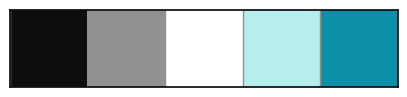

In [2]:
palette = ["#0e0e0e", 
           "#919191", 
           "#FFFFFF", 
           "#B5EEED", 
           "#0B90A7"]

params = {
    "rc": {
        "axes.facecolor": palette[2],
        "axes.grid": True,
        "grid.color": palette[1],
        "axes.edgecolor": palette[0],
        "figure.facecolor": palette[2],
        "axes.labelcolor": palette[0],
        "xtick.color": palette[0],
        "ytick.color": palette[0],
        "legend.labelcolor": palette[0],
        "legend.edgecolor": palette[2],
        "xtick.labelsize": 14,
        "ytick.labelsize":14,
        "font.size": 18,
        "font.family":"serif",
        "font.weight": "bold",

    }
}

sns.set(**params)

sns.despine()
sns.palplot(palette)

In [3]:
class CFG:
    # General
    SEED = 8615
    TARGET = 'Rings'
    ID = 'id'
    
    # Training settings
    TEST_SIZE = 0.25
    SPLITS = 15
    SHUFFLE = True
    
    # Paths
    TRAIN = '/kaggle/input/playground-series-s4e4/train.csv'
    TEST = '/kaggle/input/playground-series-s4e4/test.csv'
    SUB = '/kaggle/input/playground-series-s4e4/sample_submission.csv'
    
    # Preprocessing settings
    OHE = False
    IMPUTER_MODE = None
    IQR_THRESHOLD = 3
    USE_ORIGINAL = False
    FEATURE_ENGINEERING = False
    TRANSFORM_FEATURES = True
    
    # Plots
    BOXPLOT = {
                'boxprops': {
                    'edgecolor': '#0e0e0e',
                    'alpha': 1
                },
                'medianprops': {
                    'color': '#0e0e0e',
                    'linestyle': '-',
                    'linewidth': 0.7
                },
                'whiskerprops': {
                    'color': '#0e0e0e',
                    'linestyle': '--',
                    'linewidth': 0.7
                },
                'capprops': {
                    'color': '#0e0e0e',
                    'linewidth': 0.7
                },
                'flierprops': {
                    'marker': 'o',
                    'markersize': 4,
                    'markerfacecolor': '#fffdf7',
                    'markeredgecolor': '#0e0e0e',
                    'linewidth': 0.7
                }
            }

    TABLE = [
        {
            "selector": "tr",
            "props": [
                ("background-color", palette[-1]),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "16pt"),
                ("color", palette[2]),
                ("text-align", "center"),
                ("font-family", "serif"),
            ],
        },
        {
            "selector": "th.blank.level0",
            "props": [
                ("background-color", palette[-1])
            ],
        },
        {
            "selector": "th.blank.level0:hover",
            "props": [
                ("background-color", "#E63946"),
            ],
        },
        {
            "selector": "th:hover",
            "props": [
                ("background-color", "#E63946"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("font-size", "12pt"),
                ("font-family", "serif")
            ],
        },
        {
            "selector": "tr:hover td:hover",
            "props": [
                ("color", palette[2]),
                ("background-color", "#E63946"),
            ],
        }
    ]

class DataHandler:
    def __init__(self):
        self.train, self.test, self.sub = DataHandler.load_data([CFG.TRAIN, 
                                                                 CFG.TEST, 
                                                                 CFG.SUB])
        
        self.total = pd.concat([self.train.drop(CFG.TARGET, axis=1), self.test])
        self.total.reset_index(inplace=True, drop=True)
        
        self.viz = Visualizer(self.train, self.test, self.sub, self.total)
    
    def get_data(self):
        return self.train.copy(), self.test.copy()
    
    @staticmethod
    def load_data(paths:list, params={}, id_col=None) -> list:
        dataframes = []
        for path in paths:
            dataframes.append(pd.read_csv(path, **params))
            dataframes[-1].drop(CFG.ID, axis=1, inplace=True)
        
        return dataframes

    
class Visualizer:
    def __init__(self, train, test, target, total):
        self.train = train
        self.test = test
        self.target = target
        self.total = total
    
    def plot_kde(self, cols=3, fill=True, figsize=(15, 8), alpha=.5, linewidth=.75, colors=["#0F4BBD", "#BD280F"], title=None, legpos=(.5, 1.03)) -> None:
        numeric_cols = self.train.select_dtypes(include='number').columns
        numeric_cols = numeric_cols.drop(CFG.TARGET)
        rows = np.ceil(len(numeric_cols) / cols).astype(int)

        fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

        for i, x in enumerate(numeric_cols):
            current_ax = ax[i // cols, i % cols]
            current_ax.grid(alpha=alpha, axis='both')
            sns.kdeplot(x=x,
                        color=colors[0],
                        fill=fill,
                        linewidth=linewidth,
                        alpha=alpha,
                        data=self.train,
                        label='Train',
                        ax=current_ax)
            sns.kdeplot(x=x,
                        color=colors[1],
                        fill=fill,
                        linewidth=linewidth,
                        alpha=alpha,
                        data=self.test,
                        label='Test',
                        ax=current_ax)
            current_ax.set_xlabel(x)

        fig.legend(labels=['Train', 'Test'], loc='upper center', bbox_to_anchor=legpos, ncol=2)

        if title:
            fig.suptitle(title, fontsize=16, fontweight='bold')

        if len(numeric_cols) < (rows * cols):
            for i in range(len(numeric_cols), rows * cols):
                fig.delaxes(ax.flatten()[i])

        fig.tight_layout()
        plt.show()
    
    def show_target_distribution(self) -> None:
        self.train[CFG.TARGET].value_counts().plot(kind='bar')
    
    @staticmethod
    def corr_matrix(matrix, figsize=(15,15), 
                    cmap=sns.diverging_palette(5, 200, sep=10, s=100, l=55, as_cmap=True), 
                    title='Correlation Matrix', 
                    mask=True, 
                    round_=2,
                    linewidths=0.1) -> None:
        if mask:
            mask = np.triu(np.ones_like(
                           matrix.corr(), 
                           dtype=bool))
    
        fig = plt.figure(figsize=figsize)
        ax = sns.heatmap(matrix,
                        annot=True,
                        cmap=cmap,
                        fmt=f'.{round_}f',
                        square=True,
                        mask=mask,
                        linewidths=linewidths,
                        linecolor=palette[2],
                        vmin=-1.1,
                        vmax=1.1)
        
        ax.xaxis.grid(False)
        ax.yaxis.grid(False)

        plt.title(title, fontsize=16, fontweight='bold')
        plt.show()
    
    def plot_matrices(self, 
                  figsize=(13,10), 
                  cmap=sns.diverging_palette(5, 200, sep=10, s=100, l=55, as_cmap=True), 
                  mask=True,
                  annot=False,
                  round_=2,
                  linewidths=0.1,
                  annot_fontsize=8) -> None:
        numeric_cols = self.total.select_dtypes(include='number').columns
        corr_tr = self.train[numeric_cols].corr()
        corr_tt = self.test[numeric_cols].corr()

        if mask:
            mask = np.triu(np.ones_like(corr_tr, dtype=bool))

        fig, ax = plt.subplots(1, 2, figsize=figsize)

        sns.heatmap(
            corr_tr, 
            mask=mask, 
            cmap=cmap,
            annot=annot, 
            square=True, 
            cbar=False,
            fmt=f'.{round_}f',
            vmin=-1.1,
            vmax=1.1,
            linewidths=linewidths,
            linecolor=palette[2],
            annot_kws={"fontsize": annot_fontsize},
            ax=ax[0]
        );

        sns.heatmap(
            corr_tt, 
            mask=mask, 
            cmap=cmap,
            fmt=f'.{round_}f',
            annot=annot,
            square=True, 
            vmin=-1.1,
            vmax=1.1,
            cbar=False,
            linewidths=linewidths,
            linecolor=palette[2],
            annot_kws={"fontsize": annot_fontsize},
            ax=ax[1]
        );

        ax[0].set_title('Correlation Matrix (Train)', size=12, fontweight='bold')
        ax[1].set_title('Correlation Matrix (Test)', size=12, fontweight='bold')
        
        ax[0].xaxis.grid(False)
        ax[0].yaxis.grid(False)
        ax[1].xaxis.grid(False)
        ax[1].yaxis.grid(False)

        fig.tight_layout()
        plt.show()

    @staticmethod
    def plot_boxplot(df, 
                     target, 
                     cols=3, 
                     alpha=.8, 
                     palette='mako',
                     figsize=(15, 8), 
                     y_title=None, 
                     title=None) -> None:
        
        numeric_cols = df.select_dtypes(include='number').columns
        numeric_cols = numeric_cols.drop(CFG.TARGET)
        rows = np.ceil(len(numeric_cols) / cols).astype(int)
    
        fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

        yt_labels = []
        for i, x in enumerate(numeric_cols):
            current_ax = ax[i // cols, i % cols]
            current_ax.grid(alpha=alpha, axis='x') 
            sns.boxplot(data=df, y=target, ax=current_ax, x=x, orient='h', palette=palette, **CFG.BOXPLOT)
            current_ax.set_xlabel(x)

            if y_title and i % cols == 0:
                if len(yt_labels) == 0:
                    yt_labels = [label.get_text() for label in current_ax.get_yticklabels()]
                current_ax.set_ylabel(y_title)
                current_ax.set_yticklabels(yt_labels)
            else:
                current_ax.set_ylabel('')
                current_ax.set_yticklabels('')

        if len(numeric_cols) < (rows * cols):
            for i in range(len(numeric_cols), rows * cols):
                fig.delaxes(ax.flatten()[i])

        if title:
            fig.suptitle(title, fontsize=18, fontweight='bold')

        fig.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_regplot(df, 
                     cols=3, 
                     figsize=(15, 8), 
                     alpha=.05, 
                     colors=["#0F4BBD", "#BD280F"], 
                     title=None) -> None:
        num_cols = df.select_dtypes(include='number').columns
        num_cols = num_cols.drop(CFG.TARGET)

        rows = np.ceil(len(num_cols)/cols).astype(int)
        fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

        for i, x in enumerate(num_cols):
            current_ax = ax[i // cols, i % cols]
            current_ax.grid(alpha=alpha, axis='both')
            corr = round(df[[x, CFG.TARGET]].corr().iloc[0, 1], 2)
            sns.regplot(data = df,
                        x = x,
                        y = CFG.TARGET,
                        ax = current_ax,
                        scatter_kws = {'alpha': alpha,
                                       'color' : colors[0]},
                        line_kws = {'color': colors[1],
                                    'linestyle' : '--'},
                        )

            current_ax.set_title(f'{x} (Corr : {corr})')
            current_ax.set_xlabel('')

        if title:
            fig.suptitle(title, fontsize=16, fontweight='bold')

        if len(num_cols) < (rows * cols):
            for i in range(len(num_cols), rows * cols):
                fig.delaxes(ax.flatten()[i])

        fig.tight_layout()
        plt.show()
    
    @staticmethod
    def display_data_info(df, name) -> None:
        matrix = pd.DataFrame(index=df.columns)
        total_missing = df.isnull().sum().sum()

        matrix['Count'] = df.shape[0]
        matrix['#Null'] = df.isnull().sum()
        matrix['%Null'] = df.isnull().mean().round(3)
        matrix['Unique'] = df.nunique()

        numerical_cols = df.select_dtypes(include=[np.number]).columns
        matrix.loc[numerical_cols, 'Mean'] = df[numerical_cols].mean()
        matrix.loc[numerical_cols, 'Std'] = df[numerical_cols].std()
        matrix.loc[numerical_cols, 'Min'] = df[numerical_cols].min()
        matrix.loc[numerical_cols, 'Q1'] = df[numerical_cols].quantile(0.25)
        matrix.loc[numerical_cols, 'Q2'] = df[numerical_cols].median()
        matrix.loc[numerical_cols, 'Q3'] = df[numerical_cols].quantile(0.75)
        matrix.loc[numerical_cols, 'Max'] = df[numerical_cols].max()

        display(matrix.sort_values(['Mean']))

        return f'\n{"-"*18}\n{name} Summary:\nTotal Entries: {df.shape[0]}\nTotal Features: {df.shape[1]}\nTotal Missing Values: {total_missing}\n{"-"*18}'
    
    def __str__(self) -> str:
        summary_train = ''
        summary_test = ''
        
        print('Train Dataset')
        summary_train += Visualizer.display_data_info(self.train, 'Train')
        
        print('Test Dataset')
        summary_test += Visualizer.display_data_info(self.test, 'Test')
        return summary_train + summary_test

class Processor:
    def  __init__(self, train, test, models, logtransform):
        self.oof_train = pd.DataFrame()
        self.oof_test = pd.DataFrame()
        self.val_scores = pd.DataFrame()
        self.logtransform = logtransform
        
        self.X = train.drop(CFG.TARGET, axis=1)
        self.y = train[CFG.TARGET]
        self.test = test
        
        self.models = models
        
    def process(self):
        for name, model in self.models:
            print(name)
            self.cross_val_score(name, model)
            print()
    
    def cross_val_score(self, name, model):
        oof_tr = np.zeros(self.X.shape[0])
        oof_tt = np.zeros(self.test.shape[0])
        oof_cv = np.zeros((CFG.SPLITS, self.test.shape[0]))
        val_scores = []
        
        cv = KFold(n_splits=CFG.SPLITS, 
                   shuffle=CFG.SHUFFLE,
                   random_state=True)
        
        for i, (train_index, test_index) in tqdm(enumerate(cv.split(self.X, self.y))):
            X_train, y_train = self.X.iloc[train_index], self.y.iloc[train_index]
            X_test, y_test = self.X.iloc[test_index], self.y.iloc[test_index]

            clf = model
            
            if self.logtransform and "Classifier" not in name:
                clf.fit(X_train, np.log1p(y_train))
                oof_tr[test_index] = np.clip(np.expm1(clf.predict(X_test)), a_min=1, a_max=29)
                oof_cv[i, :] =  np.clip(np.expm1(clf.predict(self.test)), a_min=1, a_max=29)
            
            else:
                clf.fit(X_train, y_train)
                oof_tr[test_index] = np.clip(clf.predict(X_test), a_min=1, a_max=29)
                oof_cv[i, :] =  np.clip(clf.predict(self.test), a_min=1, a_max=29)
                
            rmsle_value = mean_squared_log_error(y_test, oof_tr[test_index], squared=False)
            val_scores.append(rmsle_value)
            
        print(f'Mean RMSLE: {np.array(val_scores).mean().round(4)} ± {np.array(val_scores).std().round(6)} \n')
        self.oof_train[name] = oof_tr
        self.oof_test[name] = oof_cv.mean(axis=0)
        self.val_scores[name] = val_scores
        
    @staticmethod
    def process_datasets(datasets, models, logtransform=False):
        processors_oof_train = {k:[] for k in datasets}
        processors_oof_test = {k:[] for k in datasets}
        val_scores = {k:[] for k in datasets}

        for name, (tr, tt) in datasets.items():
            print(f"Creating processor: {name}")
            processor = Processor(tr, tt, models, logtransform)
            processor.process()
            processors_oof_train[name] = processor.oof_train
            processors_oof_test[name]  = processor.oof_test
            val_scores[name] = processor.val_scores

        return processors_oof_train, processors_oof_test, val_scores

<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Data Loading" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Data Loading</h1>
</div>

In [4]:
data = DataHandler()

print(data.viz)

Train Dataset


,Count,#Null,%Null,Unique,Mean,Std,Min,Q1,Q2,Q3,Max
Height,90615,0,0.0,90,0.135464,0.038008,0.0000,0.1100,0.1400,0.1600,1.1300
Whole weight.2,90615,0,0.0,979,0.169422,0.100909,0.0005,0.0865,0.1660,0.2325,0.7600
Shell weight,90615,0,0.0,1129,0.225898,0.130203,0.0015,0.1200,0.2250,0.3050,1.0050
Whole weight.1,90615,0,0.0,1799,0.340778,0.204428,0.0010,0.1775,0.3300,0.4630,1.4880
Diameter,90615,0,0.0,126,0.401679,0.098026,0.0550,0.3450,0.4250,0.4700,0.6500
Length,90615,0,0.0,157,0.517098,0.118217,0.0750,0.4450,0.5450,0.6000,0.8150
Whole weight,90615,0,0.0,3175,0.789035,0.457671,0.0020,0.4190,0.7995,1.0675,2.8255
Rings,90615,0,0.0,28,9.696794,3.176221,1.0000,8.0000,9.0000,11.0000,29.0000
Sex,90615,0,0.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Test Dataset


,Count,#Null,%Null,Unique,Mean,Std,Min,Q1,Q2,Q3,Max
Height,60411,0,0.0,85,0.135751,0.038175,0.0000,0.1100,0.1400,0.1600,1.0950
Whole weight.2,60411,0,0.0,960,0.169419,0.100720,0.0005,0.0865,0.1660,0.2325,0.6415
Shell weight,60411,0,0.0,1089,0.226125,0.129826,0.0015,0.1200,0.2250,0.3050,1.0040
Whole weight.1,60411,0,0.0,1747,0.341227,0.204221,0.0010,0.1785,0.3290,0.4645,1.4880
Diameter,60411,0,0.0,130,0.401961,0.097470,0.0550,0.3450,0.4250,0.4700,0.6500
Length,60411,0,0.0,148,0.517428,0.117609,0.0750,0.4500,0.5450,0.6000,0.8000
Whole weight,60411,0,0.0,3037,0.790062,0.457591,0.0020,0.4195,0.8015,1.0700,2.8255
Sex,60411,0,0.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN



------------------
Train Summary:
Total Entries: 90615
Total Features: 9
Total Missing Values: 0
------------------
------------------
Test Summary:
Total Entries: 60411
Total Features: 8
Total Missing Values: 0
------------------


<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Exploratory Data Analysis" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Exploratory Data Analysis</h1>
</div>

### **How is the target variable distributed?**

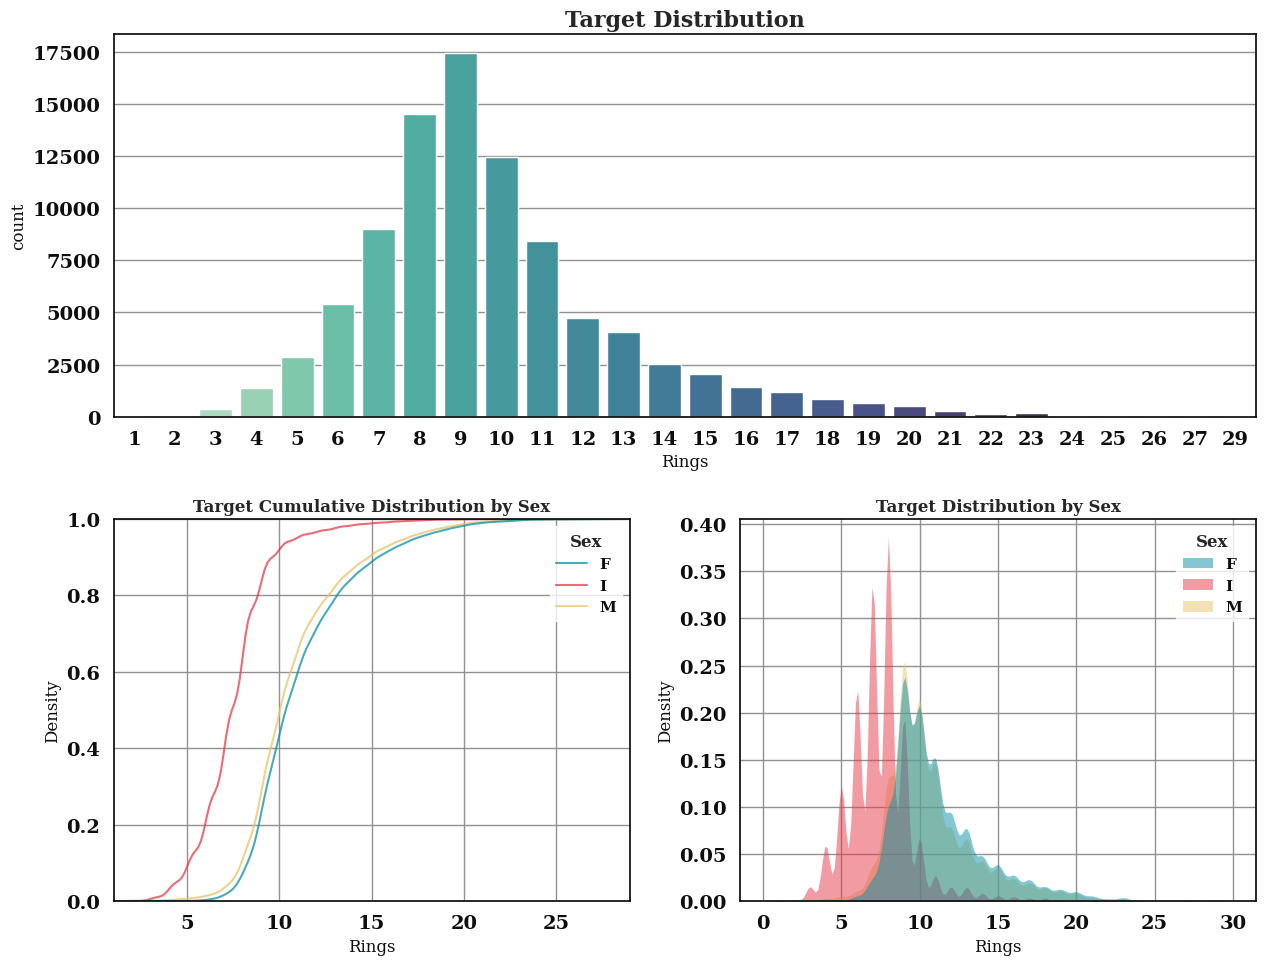

In [5]:
fig = plt.figure(constrained_layout=True, figsize=(13, 10))
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

sns.countplot(data.train, x=CFG.TARGET, palette="mako_r", ax=ax1)
sns.kdeplot(data.train, x=CFG.TARGET, palette=['#0B90A7','#E63946', '#E9C46A'], ax=ax2, hue='Sex', alpha=.75, cumulative=True, common_norm=False, common_grid=True)
sns.kdeplot(data.train, x=CFG.TARGET, palette=['#0B90A7','#E63946', '#E9C46A'], hue='Sex', alpha=.5, linewidth=0, common_grid=True, common_norm=False, fill=True)

ax2.set_xlim(data.train["Rings"].min(), data.train["Rings"].max())
ax2.set_ylim(0, 1)

ax1.set_title('Target Distribution', size=16, fontweight='bold')
ax2.set_title('Target Cumulative Distribution by Sex', size=12, fontweight='bold')
ax3.set_title('Target Distribution by Sex', size=12, fontweight='bold')

fig.tight_layout()
plt.show()

### **How are features distributed?**

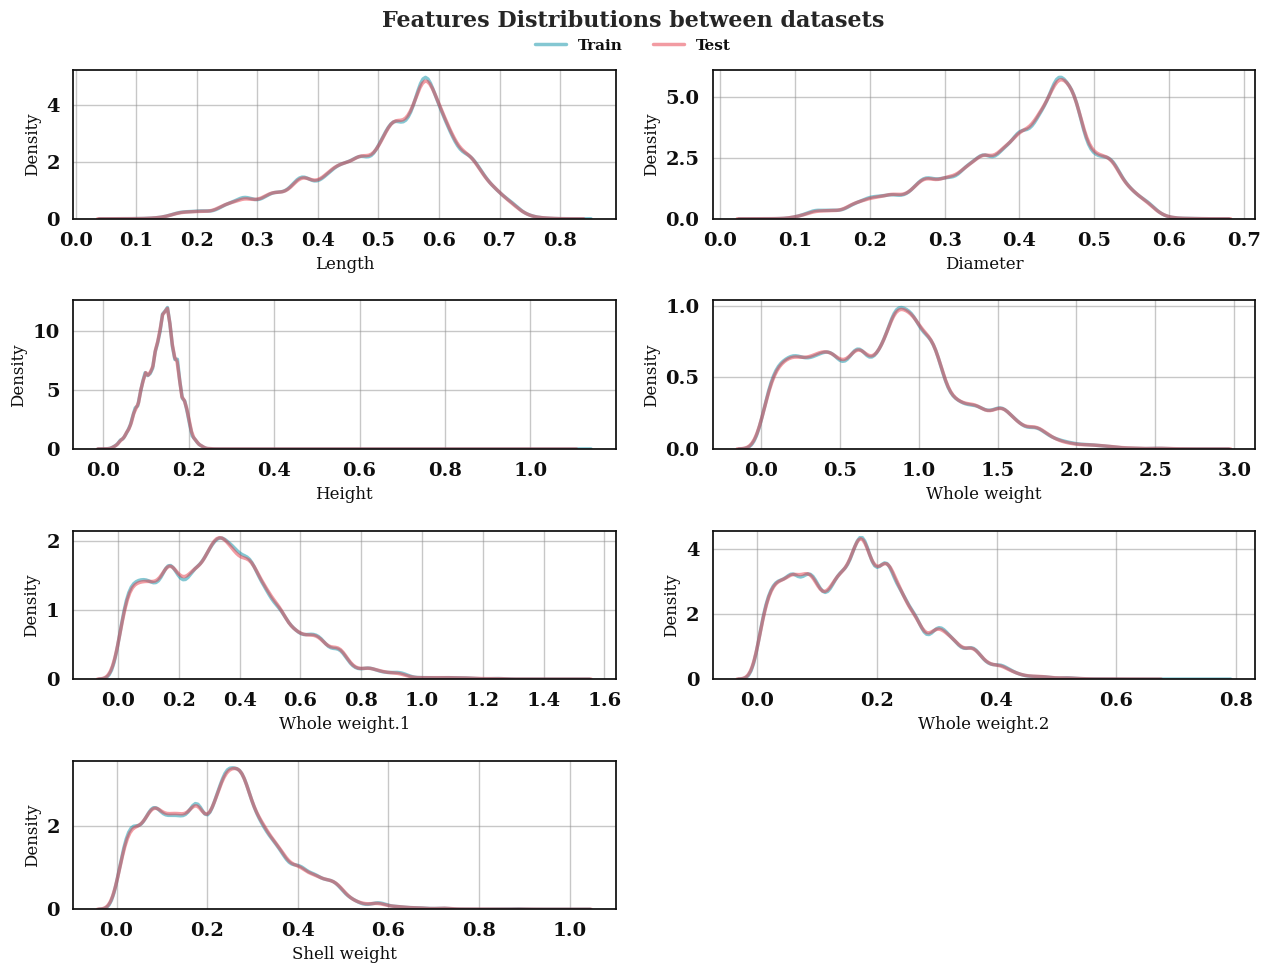

In [6]:
data.viz.plot_kde(
    title="Features Distributions between datasets",
    colors=['#0B90A7','#E63946'], 
    fill=False, 
    linewidth=2.5, 
    cols=2, 
    figsize=(13, 10), 
    legpos=(.5, .965)
)

In [7]:
temp = data.train.copy()

temp["Rings Interval"] = pd.cut(temp.Rings,bins=[0, 6, 12, 18, 24, 30],
                                labels=['0-6', '6-12', '12-18', '18-24', '24-30'])

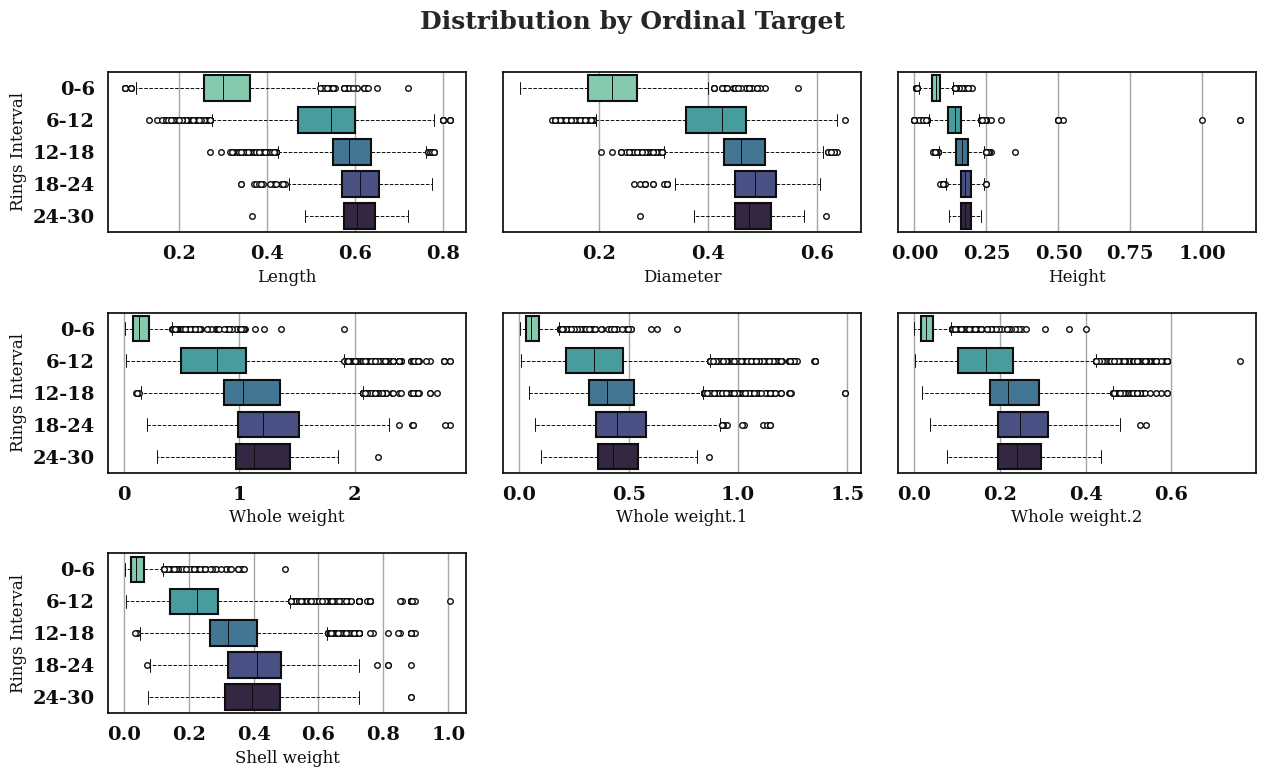

In [8]:
Visualizer.plot_boxplot(temp, 
                        'Rings Interval', 
                        figsize=(13, 8), 
                        title='Distribution by Ordinal Target', 
                        palette='mako_r', 
                        y_title="Rings Interval")

### **How are features correlated?**

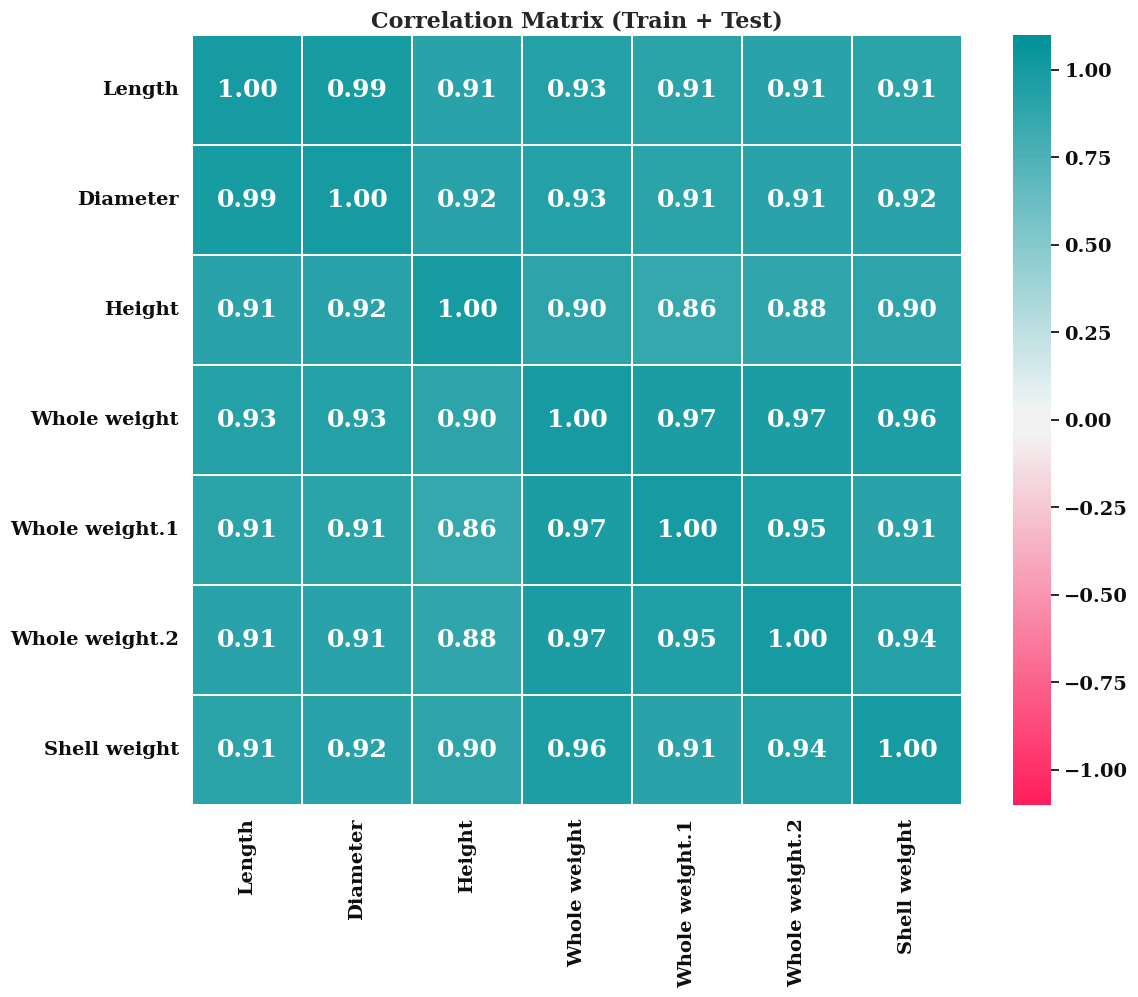

In [9]:
data.viz.corr_matrix(
    data.total.corr(numeric_only=True), 
    mask=False, 
    linewidths=0.01, 
    figsize=(13,10), 
    title="Correlation Matrix (Train + Test)"
)

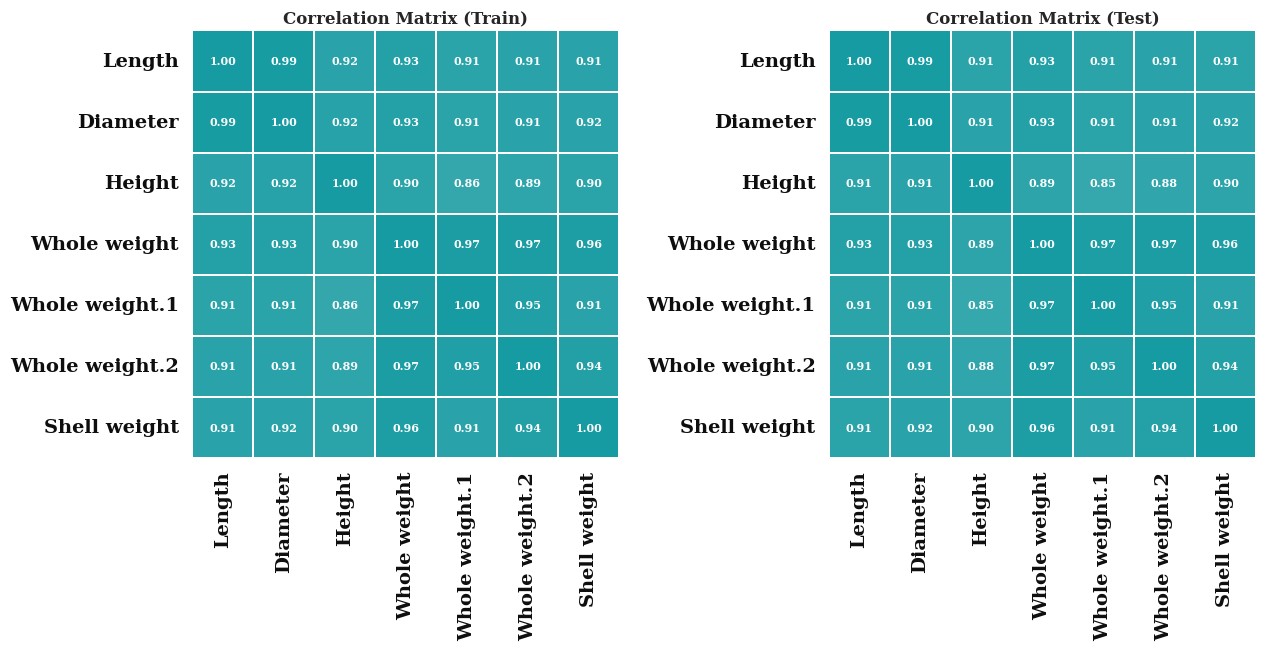

In [10]:
data.viz.plot_matrices(
    annot=True, 
    linewidths=0.01, 
    mask=False
)

### **What do height outliers look like?**

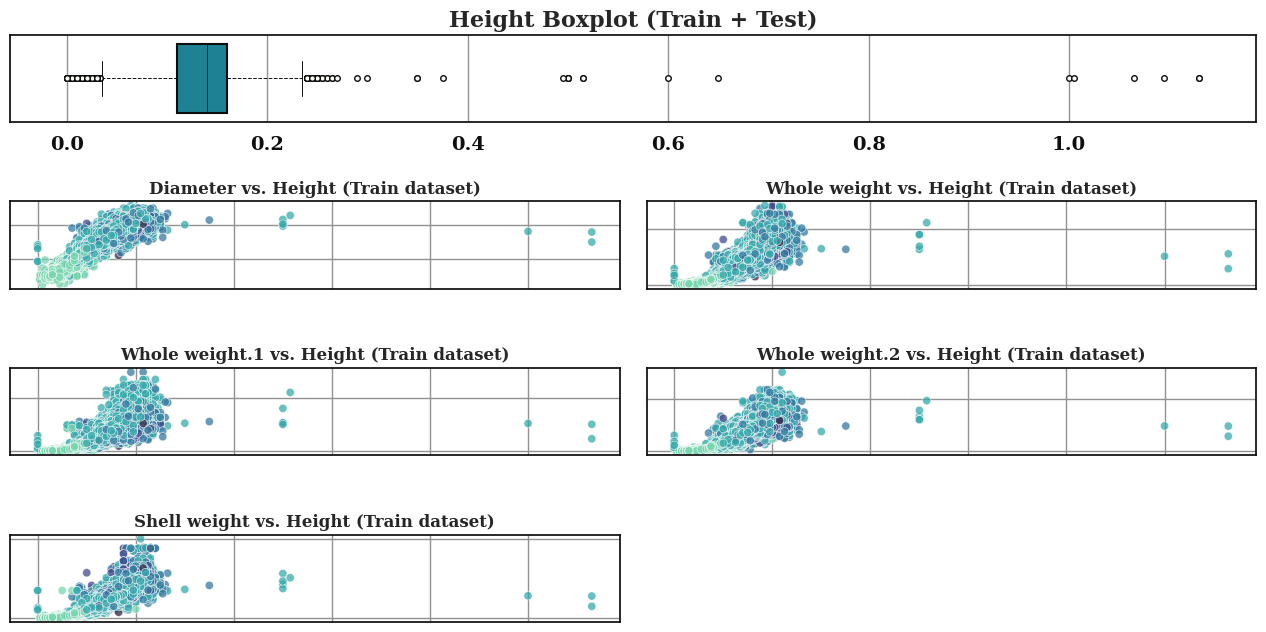

In [11]:
num_cols = temp.drop([CFG.TARGET, 'Height'], axis=1).select_dtypes(include='number').columns
n = int(np.ceil(len(num_cols)))

fig = plt.figure(constrained_layout=True, figsize=(13, 10))
gs = GridSpec(n, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
sns.boxplot(data=data.total, x="Height", color=palette[4], ax=ax1, **CFG.BOXPLOT)
ax1.set_title('Height Boxplot (Train + Test)', size=16, fontweight='bold')
ax1.set_xlabel('')

for i in range(1, n):
    row = (i + 1) // 2
    col = (i + 1) % 2
    ax = fig.add_subplot(gs[row, col])
    sns.scatterplot(data=temp, 
                    x='Height', 
                    y=num_cols[i], 
                    hue='Rings Interval', 
                    palette='mako_r',
                    color=palette[4], 
                    alpha=.75, 
                    ax=ax, 
                    legend=False)
    ax.set(xticklabels=[], yticklabels=[])
    ax.set_title(f'{num_cols[i]} vs. Height (Train dataset)', size=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Validation" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Validation</h1>
</div>

In [12]:
train, test = data.get_data()

In [13]:
lgb_params = {
    "num_leaves": 57,
    "learning_rate": 0.03440451906502543,
    "bagging_freq": 68,
    "n_estimators": 724,
    "subsample": 0.9007055349740095,
    "colsample_bytree": 0.593788520597921,
    "reg_alpha": 0.9516296103830201,
    "reg_lambda": 0.4758848445437453,
    "min_child_samples": 46,
    "min_child_weight": 5,
    "max_depth": 18,
    'random_state':CFG.SEED, 
    'n_jobs': -1,
    'verbose': -1,
}

xgb_params = {
    "eta": 0.03740451615611283,
    "gamma": 0.05406894998707229,
    "min_child_weight": 2,
    "max_depth": 81,
    "colsample_bytree": 0.6828373910204858,
    "n_estimators": 939,
    "subsample": 0.5425657702561839,
    "reg_alpha": 0.6160784333191124,
    "reg_lambda": 2.216998584184299,
    "max_bin": 895,
    "grow_policy": "depthwise",
    'random_state': CFG.SEED,
    'verbose': -1,
    'objective': 'reg:squarederror'
}

cat_params = {
    "bagging_temperature": 3.003798427216796,
    "colsample_bylevel": 0.9971552236228259,
    "learning_rate": 0.07732071551909009,
    "max_depth": 5,
    "max_bin": 659,
    "grow_policy": "Depthwise",
    "subsample": 0.5034422434771387,
    "iterations": 1293,
    "l2_leaf_reg": 5.282327062630202,
    "min_data_in_leaf": 54,
    "random_strength": 0.4227369390952206,
    'random_state': CFG.SEED,
    'verbose': False
}

rf_params = {
    "max_leaf_nodes": 974,
    "min_samples_split": 28,
    "min_samples_leaf": 7,
    'random_state': CFG.SEED
}

hb_params = {
    "learning_rate": 0.07609507300153473,
    "max_depth": 8,
    "quantile": 0.27319697409085053,
    "max_iter": 1307,
    "l2_regularization": 0.21500659260289745,
    "min_samples_leaf": 89,
    'random_state': CFG.SEED
}

gb_params = {
    'criterion': 'squared_error',
    'loss': 'huber',
    'learning_rate': 0.8008823024800019,
    'n_estimators': 118,
    'min_samples_leaf': 48,
    'min_weight_fraction_leaf': 0.010199254478299613,
    'verbose': 0,
    'random_state': CFG.SEED
}

In [14]:
models = [
    ('RF', Pipeline([
        ('target_enc', TargetEncoder()),
       ('rf', RandomForestRegressor(**rf_params))
    ])),
    ('HB', Pipeline([
        ('target_enc', TargetEncoder()),
        ('hb', HistGradientBoostingRegressor(**hb_params))
    ])),
    ('LGB', Pipeline([
        ('target_enc', TargetEncoder()),
        ('lgb', LGBMRegressor(**lgb_params))
    ])),
    ('XGB', Pipeline([
        ('binary_enc', BinaryEncoder()),
        ('xgb', XGBRegressor(**xgb_params))
    ])),
    ('CAT', Pipeline([
        ('target_enc', TargetEncoder()),
        ('cat', CatBoostRegressor(**cat_params))
    ])),
]

In [15]:
first_layer = Processor(train, test, models, logtransform=True)
first_layer.process()

oof_train = first_layer.oof_train.copy()
oof_train[CFG.TARGET] = data.train[CFG.TARGET].copy()
oof_test = first_layer.oof_test.copy()

RF


15it [07:03, 28.25s/it]


Mean RMSLE: 0.1497 ± 0.002813 


HB


15it [00:45,  3.01s/it]


Mean RMSLE: 0.1492 ± 0.002775 


LGB


...

Mean RMSLE: 0.1478 ± 0.002766 


XGB


15it [02:20,  9.38s/it]


Mean RMSLE: 0.1479 ± 0.002839 


CAT


15it [06:13, 24.90s/it]

Mean RMSLE: 0.1479 ± 0.002809 




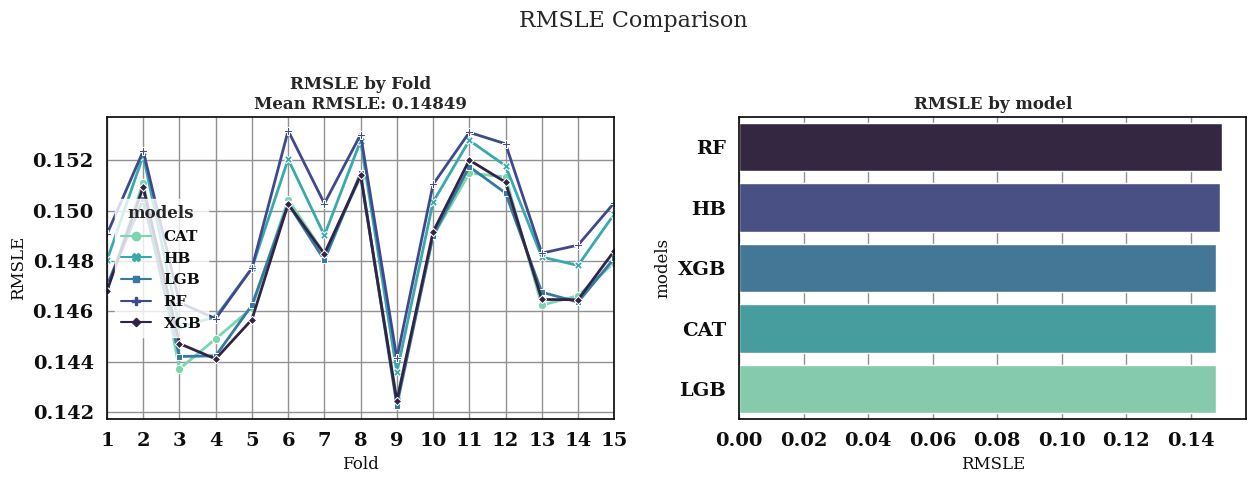

In [16]:
val_scores = first_layer.val_scores

val_scores = val_scores.stack().reset_index().sort_values('level_1').rename({"level_0": "Fold", "level_1": "models", 0: "RMSLE"}, axis=1).reset_index(drop=True)

cols = 2
rows = 1
figsize = (13, 5)

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)
ax1 = ax[0]
ax2 = ax[1]

val_scores["Fold"] = val_scores["Fold"] + 1
sns.lineplot(data=val_scores, 
             x='Fold', 
             y='RMSLE', 
             style='models', 
             hue='models',
             markers=True,
             dashes=False,
             palette='mako_r',
             linewidth=2,
             ax=ax1)

mean_values = val_scores.groupby("models")["RMSLE"].mean().reset_index().sort_values("RMSLE", ascending=False)
sns.barplot(y='models', 
            x='RMSLE', 
            palette="mako", 
            data=mean_values, ax=ax2)

ax1.set_title(f'RMSLE by Fold\nMean RMSLE: {round(val_scores.RMSLE.mean(), 5)}', size=12, fontweight='bold')
ax2.set_title(f'RMSLE by model', size=12, fontweight='bold')
ax1.set_xlim(min(val_scores["Fold"]), max(val_scores["Fold"]))
ax1.set_xticks([*range(1, len(first_layer.val_scores) + 1)])
    
plt.suptitle("RMSLE Comparison", fontsize=16) 
fig.tight_layout()
plt.show()

In [17]:
meta_estimators = [
    ('Huber', HuberRegressor()),
    ('Theil', TheilSenRegressor()),
    ('Ridge', Ridge(random_state=CFG.SEED)),
]

final_model = [
    ('VR', VotingRegressor(meta_estimators)),
]

model = Processor(oof_train, oof_test, final_model, logtransform=False)
model.process()

VR


15it [05:53, 23.59s/it]

Mean RMSLE: 0.1474 ± 0.0028 




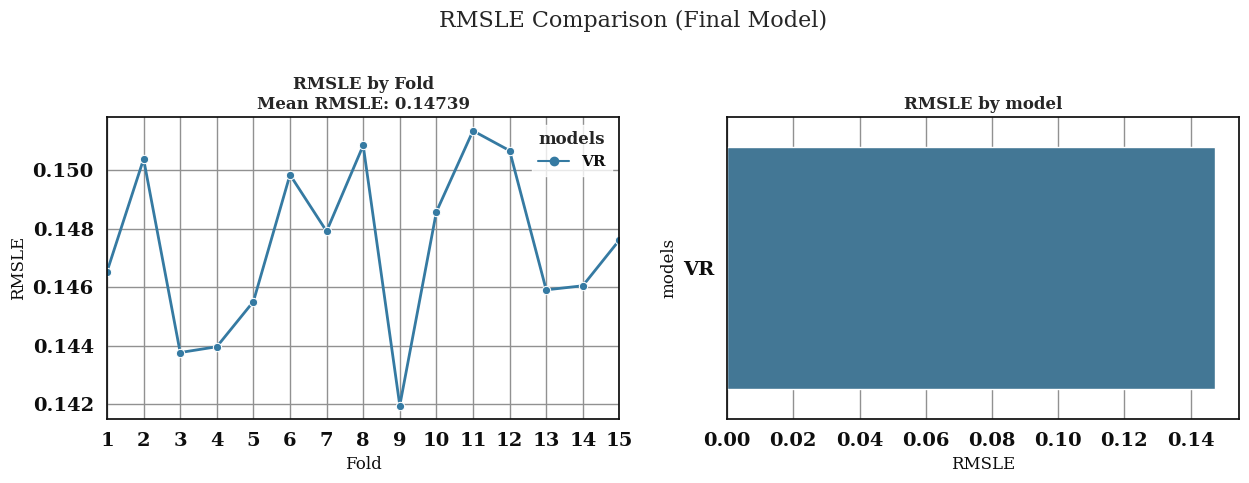

In [18]:
val_scores = model.val_scores.copy()

val_scores = val_scores.stack().reset_index().sort_values('level_1').rename({"level_0": "Fold", "level_1": "models", 0: "RMSLE"}, axis=1).reset_index(drop=True)

cols = 2
rows = 1
figsize = (13, 5)

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)
ax1 = ax[0]
ax2 = ax[1]

val_scores["Fold"] = val_scores["Fold"] + 1
sns.lineplot(data=val_scores, 
             x='Fold', 
             y='RMSLE', 
             style='models', 
             hue='models',
             markers=True,
             dashes=False,
             palette='mako_r',
             linewidth=2,
             ax=ax1)

mean_values = val_scores.groupby("models")["RMSLE"].mean().reset_index().sort_values("RMSLE", ascending=False)
sns.barplot(y='models', 
            x='RMSLE', 
            palette="mako", 
            data=mean_values, 
            ax=ax2)

ax1.set_title(f'RMSLE by Fold\nMean RMSLE: {round(val_scores.RMSLE.mean(), 5)}', size=12, fontweight='bold')
ax2.set_title(f'RMSLE by model', size=12, fontweight='bold')
ax1.set_xlim(min(val_scores["Fold"]), max(val_scores["Fold"]))
ax1.set_xticks([*range(1, len(model.val_scores) + 1)])
    
plt.suptitle("RMSLE Comparison (Final Model)", fontsize=16) 
fig.tight_layout()
plt.show()

### **Where are the model's greatest errors?**

In [19]:
greatest_error = first_layer.oof_train.copy()
greatest_error["Predicted"] = model.oof_train.values
greatest_error["Rings"] = data.train[CFG.TARGET]
 
greatest_error["RSLE"] = np.sqrt((np.log1p(greatest_error['Predicted']) - np.log1p(greatest_error['Rings']))**2)

q1 = greatest_error["RSLE"].quantile(0.25)
q3 = greatest_error["RSLE"].quantile(0.75)
iqr = q3 - q1
        
greatest_diffs = greatest_error.loc[(greatest_error["RSLE"] > q3 + 1.5 * iqr) | 
                                    (greatest_error["RSLE"] < q1 - 1.5 * iqr)
                                   ].sort_values(by='RSLE', ascending=False)

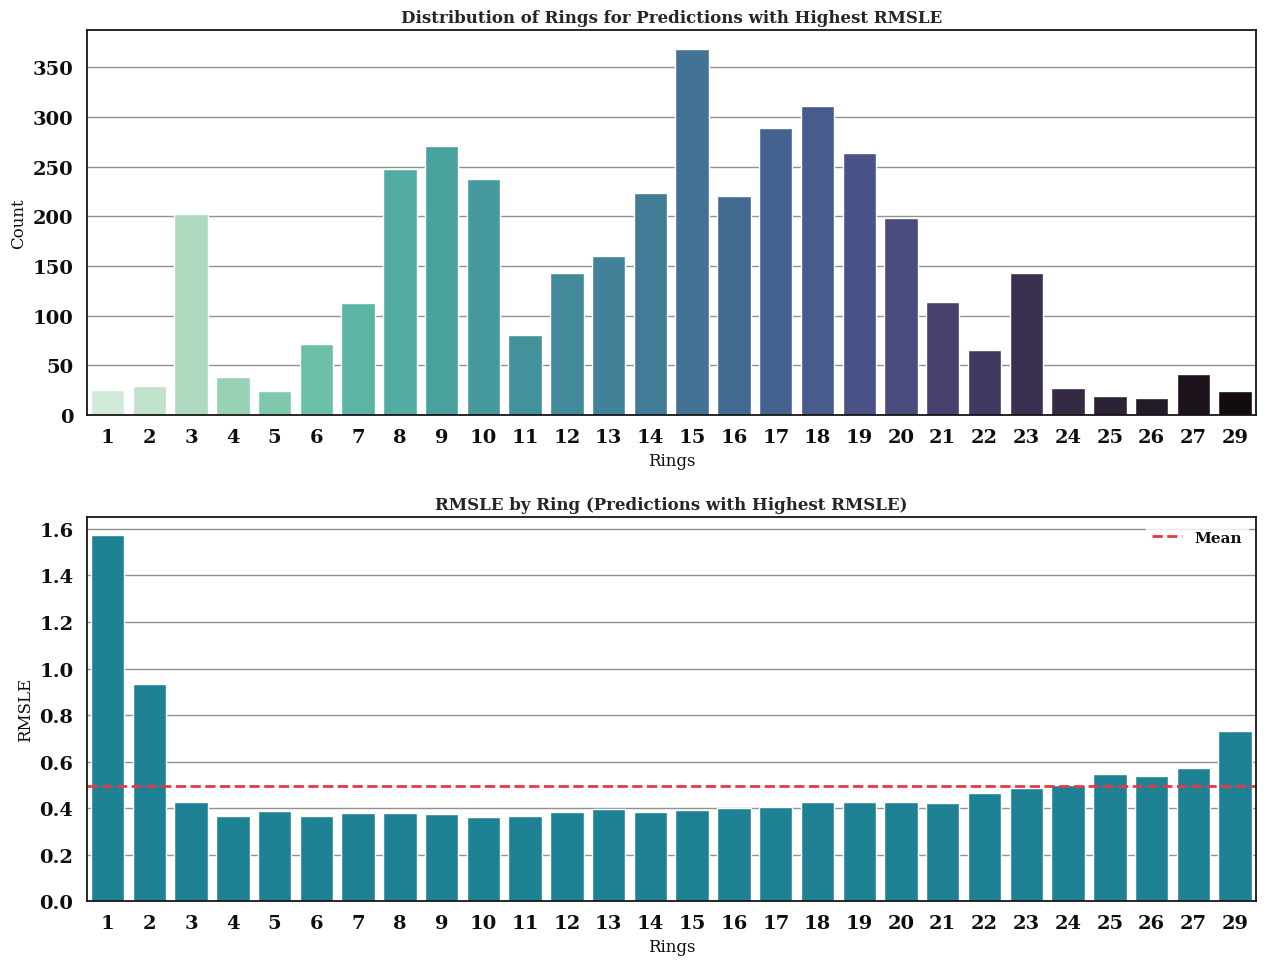

In [20]:
temp = greatest_diffs.Rings.value_counts().sort_index().reset_index()

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(13, 10))
ax1 = ax[0]
ax2 = ax[1]

sns.barplot(data=temp, x="Rings", y="count", palette='mako_r', ax=ax1)

sns.barplot(greatest_diffs.groupby("Rings")["RSLE"].mean().reset_index(),
            x="Rings",
            y="RSLE",
            color=palette[4],
            ax=ax2)

ax2.axhline(y=greatest_diffs.groupby("Rings")["RSLE"].mean().reset_index()["RSLE"].mean(), color='#E63946', linestyle='--', linewidth=2, label='Mean')
ax1.set_title(f'Distribution of Rings for Predictions with Highest RMSLE', size=12, fontweight='bold')
ax2.set_title(f'RMSLE by Ring (Predictions with Highest RMSLE)', size=12, fontweight='bold')
ax2.set_ylabel('RMSLE')
ax1.set_ylabel('Count')
ax2.legend()

fig.tight_layout()
plt.show()

<div style="font-family: 'serif'; color: #1b1b1b">
    <h1 id="Submission" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Submission</h1>
</div>

In [21]:
sub = pd.read_csv("/kaggle/input/playground-series-s4e4/sample_submission.csv")

sub["Rings"] = model.oof_test
sub.to_csv('submission.csv', index=False)

sub["Rings"] = oof_test.mean(axis=1)
sub.to_csv('oof_test.csv', index=False)

<div style="font-family: 'serif'; color: #1b1b1b;">
<h1 id="Bookmarks" style="border-bottom: 5px dashed #0B90A7; padding-bottom: 5px;">Bookmarks</h1>
<h3>Bookmarked in this competition: </h3>
<ul>
    <li><a href="https://www.kaggle.com/competitions/playground-series-s3e16/discussion/416769">#5 Solution | five models + LADRegression</a></li>
    <li><a href="https://www.kaggle.com/code/mpwolke/abalonesscatters-ransac-huber-ols?rvi=1">AbalonesScatters: RANSAC, Huber & OLS</a></li>
    <li><a href="https://www.kaggle.com/code/khsamaha/abalone-eda-ensemble-stacking-method-r">Abalone | EDA | Ensemble Stacking Method | R</a></li>
    <li><a href="https://www.kaggle.com/code/arunklenin/ps4e4-prediction-generalization-regression">PS4E4 | Prediction Generalization | Regression</a></li>
    <li><a href="https://www.kaggle.com/code/satyaprakashshukl/random-search-neural-network-abalone">🥅Random Search 🥽Neural Network🙏🏽Abalone🎨</a></li>
</ul>
</div>